In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
SEED = 42
random.seed(SEED)

In [ ]:
dataset_path = "/content/drive/MyDrive/SAM_Masked_1500"

In [ ]:
classes = sorted([
    cls for cls in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, cls))
])
print("Classes Found:\n")
print(classes)

Classes Found:

['Cyst', 'Normal', 'Stone', 'Tumor']


In [ ]:
all_filepaths = []
all_labels = []

valid_extensions = (
    '.png',
    '.jpg',
    '.jpeg',
    '.bmp'
)

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    images = [

        img for img in os.listdir(class_path)

        if img.lower().endswith(valid_extensions)
    ]

    print(f"{cls} --> {len(images)} images")

    for img in images:

        full_path = os.path.join(class_path, img)

        all_filepaths.append(full_path)

        all_labels.append(cls)

Cyst --> 447 images
Normal --> 611 images
Stone --> 165 images
Tumor --> 275 images


In [ ]:
df = pd.DataFrame({
    "filepath": all_filepaths,
    "label": all_labels
})
print("\nTotal Images:", len(df))


Total Images: 1498


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)
# Reset Index
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [ ]:
save_dir = "/content/drive/MyDrive/Kidney_CSV_Splits-mask"

os.makedirs(save_dir, exist_ok=True)

train_csv_path = os.path.join(save_dir, "train.csv")

test_csv_path = os.path.join(save_dir, "test.csv")

train_df.to_csv(train_csv_path, index=False)

test_df.to_csv(test_csv_path, index=False)

In [ ]:
print("\n===================================")
print("CSV Split Created Successfully!")
print("===================================")

print(f"\nTrain CSV Saved At:\n{train_csv_path}")

print(f"\nTest CSV Saved At:\n{test_csv_path}")

print("\nTrain Size:", len(train_df))
print("Test Size :", len(test_df))


CSV Split Created Successfully!

Train CSV Saved At:
/content/drive/MyDrive/Kidney_CSV_Splits-mask/train.csv

Test CSV Saved At:
/content/drive/MyDrive/Kidney_CSV_Splits-mask/test.csv

Train Size: 1198
Test Size : 300


In [ ]:
print("\n===================================")
print("TRAIN CLASS DISTRIBUTION")
print("===================================\n")

print(train_df["label"].value_counts())

print("\n===================================")
print("TEST CLASS DISTRIBUTION")
print("===================================\n")

print(test_df["label"].value_counts())


TRAIN CLASS DISTRIBUTION

label
Normal    489
Cyst      357
Tumor     220
Stone     132
Name: count, dtype: int64

TEST CLASS DISTRIBUTION

label
Normal    122
Cyst       90
Tumor      55
Stone      33
Name: count, dtype: int64


In [ ]:
summary_df = pd.DataFrame({

    "Train_Count": train_df["label"].value_counts(),

    "Test_Count": test_df["label"].value_counts()
})

summary_path = os.path.join(
    save_dir,
    "split_summary.csv"
)

summary_df.to_csv(summary_path)

print(f"\nSummary CSV Saved At:\n{summary_path}")


Summary CSV Saved At:
/content/drive/MyDrive/Kidney_CSV_Splits-mask/split_summary.csv


In [ ]:
!pip install -q open_clip_torch peft timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00


In [ ]:
import os
import copy
import time
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import open_clip

from peft import (
    LoraConfig,
    get_peft_model
)


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using Device:", device)

Using Device: cuda


In [ ]:
train_csv = "/content/drive/MyDrive/Kidney_CSV_Splits-mask/train.csv"
test_csv = "/content/drive/MyDrive/Kidney_CSV_Splits-mask/test.csv"

In [ ]:
train_df = pd.read_csv(train_csv)

test_df = pd.read_csv(test_csv)

print("Train Samples:", len(train_df))
print("Test Samples :", len(test_df))

Train Samples: 1198
Test Samples : 300


In [ ]:
classes = sorted(train_df["label"].unique())
class_to_idx = {
    cls:i for i, cls in enumerate(classes)
}
idx_to_class = {
    i:cls for cls, i in class_to_idx.items()
}
print("\nClasses:")
print(classes)


Classes:
['Cyst', 'Normal', 'Stone', 'Tumor']


In [ ]:
class KidneyDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]["filepath"]

        label = self.df.iloc[idx]["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[label]

        return image, label

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = KidneyDataset(
    train_df,
    transform=train_transform
)

test_dataset = KidneyDataset(
    test_df,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

In [ ]:
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='openai'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [ ]:
lora_config = LoraConfig(

    r=8,

    lora_alpha=16,

    target_modules=[
        "out_proj",
        "c_fc",
        "c_proj"
    ],

    lora_dropout=0.1,

    bias="none"
)

In [ ]:
trainable_params = 0
all_params = 0

for param in clip_model.visual.parameters():

    num_params = param.numel()

    all_params += num_params

    if param.requires_grad:
        trainable_params += num_params

print(f"\nTrainable Params: {trainable_params:,}")

print(f"Total Params: {all_params:,}")

print(
    f"Trainable %: {100 * trainable_params / all_params:.4f}%"
)


Trainable Params: 87,849,216
Total Params: 87,849,216
Trainable %: 100.0000%


In [ ]:
for name, param in clip_model.visual.named_parameters():
    if param.requires_grad:
        print(name)

class_embedding
positional_embedding
proj
conv1.weight
ln_pre.weight
ln_pre.bias
transformer.resblocks.0.ln_1.weight
transformer.resblocks.0.ln_1.bias
transformer.resblocks.0.attn.in_proj_weight
transformer.resblocks.0.attn.in_proj_bias
transformer.resblocks.0.attn.out_proj.weight
transformer.resblocks.0.attn.out_proj.bias
transformer.resblocks.0.ln_2.weight
transformer.resblocks.0.ln_2.bias
transformer.resblocks.0.mlp.c_fc.weight
transformer.resblocks.0.mlp.c_fc.bias
transformer.resblocks.0.mlp.c_proj.weight
transformer.resblocks.0.mlp.c_proj.bias
transformer.resblocks.1.ln_1.weight
transformer.resblocks.1.ln_1.bias
transformer.resblocks.1.attn.in_proj_weight
transformer.resblocks.1.attn.in_proj_bias
transformer.resblocks.1.attn.out_proj.weight
transformer.resblocks.1.attn.out_proj.bias
transformer.resblocks.1.ln_2.weight
transformer.resblocks.1.ln_2.bias
transformer.resblocks.1.mlp.c_fc.weight
transformer.resblocks.1.mlp.c_fc.bias
transformer.resblocks.1.mlp.c_proj.weight
transformer

In [ ]:
for param in clip_model.visual.parameters():
    param.requires_grad = False

In [ ]:
for name, param in clip_model.visual.named_parameters():
    if "lora" in name.lower():
        param.requires_grad = True

In [ ]:
cnn_model = models.efficientnet_b0(
    weights="DEFAULT"
)
cnn_features = cnn_model.classifier[1].in_features
cnn_model.classifier = nn.Identity()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


In [ ]:
class HybridModel(nn.Module):

    def __init__(self):

        super(HybridModel, self).__init__()

        self.clip_visual = clip_model.visual

        self.cnn = cnn_model

        # Projection Layers
        self.clip_proj = nn.Linear(512, 256)

        self.cnn_proj = nn.Linear(cnn_features, 256)

        # Attention Fusion
        self.attention = nn.Sequential(

            nn.Linear(512, 512),

            nn.ReLU(),

            nn.Linear(512, 512),

            nn.Softmax(dim=1)
        )

        # Classifier
        self.classifier = nn.Sequential(

            nn.Linear(512, 256),

            nn.BatchNorm1d(256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, 128),

            nn.BatchNorm1d(128),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(128, len(classes))
        )

    def forward(self, x):

        # CLIP Features
        clip_feat = self.clip_visual(x)

        clip_feat = self.clip_proj(clip_feat)

        # CNN Features
        cnn_feat = self.cnn(x)

        cnn_feat = self.cnn_proj(cnn_feat)

        # Fusion
        fused = torch.cat(
            [clip_feat, cnn_feat],
            dim=1
        )

        # Attention Fusion
        fused = torch.cat([clip_feat, cnn_feat], dim=1)

        # Classification
        output = self.classifier(fused)

        return output, fused

In [ ]:
model = HybridModel().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
patience = 3
best_val_loss = np.inf
counter = 0
best_model_wts = copy.deepcopy(
    model.state_dict()
)

In [ ]:
history = {

    "epoch": [],

    "train_loss": [],
    "train_acc": [],

    "test_loss": [],
    "test_acc": [],

    "precision": [],
    "recall": [],
    "specificity": []
}

In [ ]:
all_features = []
all_labels = []
all_predictions = []

In [ ]:
scaler = torch.amp.GradScaler('cuda')

In [ ]:
def train_one_epoch():

    model.train()

    running_loss = 0

    preds_all = []

    labels_all = []

    for images, labels in tqdm(train_loader):

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):

          outputs, features = model(images)

          loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        preds_all.extend(
            preds.cpu().numpy()
        )

        labels_all.extend(
            labels.cpu().numpy()
        )

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = accuracy_score(
        labels_all,
        preds_all
    )

    return epoch_loss, epoch_acc

In [ ]:
def evaluate():

    model.eval()

    running_loss = 0

    preds_all = []

    labels_all = []

    features_all = []

    with torch.no_grad():

        for images, labels in tqdm(test_loader):

            images = images.to(device)

            labels = labels.to(device)

            outputs, features = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            preds_all.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

            features_all.extend(
                features.cpu().numpy()
            )

    epoch_loss = running_loss / len(test_loader)

    epoch_acc = accuracy_score(
        labels_all,
        preds_all
    )

    precision = precision_score(
        labels_all,
        preds_all,
        average='weighted'
    )

    recall = recall_score(
        labels_all,
        preds_all,
        average='weighted'
    )

    cm = confusion_matrix(
        labels_all,
        preds_all
    )

    specificities = []

    for i in range(len(cm)):

        TP = cm[i, i]

        FN = np.sum(cm[i, :]) - TP

        FP = np.sum(cm[:, i]) - TP

        TN = np.sum(cm) - (TP + FN + FP)

        specificity = TN / (TN + FP + 1e-8)

        specificities.append(specificity)

    # Average Specificity
    specificity = np.mean(specificities)

    return (

        epoch_loss,

        epoch_acc,

        precision,

        recall,

        specificity,

        cm,

        labels_all,

        preds_all,

        features_all
    )

In [ ]:
epochs = 20

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    start_time = time.time()

    # TRAIN
    train_loss, train_acc = train_one_epoch()

    # EVALUATE
    (
        test_loss,
        test_acc,
        precision,
        recall,
        specificity,
        cm,
        y_true,
        y_pred,
        feature_vectors

    ) = evaluate()

    # STORE METRICS
    history["epoch"].append(epoch+1)

    history["train_loss"].append(train_loss)

    history["train_acc"].append(train_acc)

    history["test_loss"].append(test_loss)

    history["test_acc"].append(test_acc)

    history["precision"].append(precision)

    history["recall"].append(recall)

    history["specificity"].append(specificity)

    # SAVE FEATURES
    all_features.extend(feature_vectors)

    all_labels.extend(y_true)

    all_predictions.extend(y_pred)

    # PRINT RESULTS
    print(f"\nTrain Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Test Loss  : {test_loss:.4f}")

    print(f"Test Acc   : {test_acc:.4f}")

    print(f"Precision  : {precision:.4f}")

    print(f"Recall     : {recall:.4f}")

    print(f"Specificity   : {specificity:.4f}")

    # EARLY STOPPING
    if test_loss < best_val_loss:

        best_val_loss = test_loss

        best_model_wts = copy.deepcopy(
            model.state_dict()
        )

        counter = 0

        print("\nValidation Loss Improved!")

    else:

        counter += 1

        print(
            f"\nEarly Stopping Counter: {counter}/{patience}"
        )

        if counter >= patience:

            print("\nEarly Stopping Triggered!")

            break

    epoch_time = time.time() - start_time

    print(f"\nEpoch Time: {epoch_time:.2f} sec")


Epoch 1/20


100%|██████████| 38/38 [00:52<00:00,  1.39s/it]



Train Loss : 1.0409
Train Acc  : 0.5860
Test Loss  : 0.6714
Test Acc   : 0.8267
Precision  : 0.8303
Recall     : 0.8267
Specificity   : 0.9339

Validation Loss Improved!

Epoch Time: 279.41 sec

Epoch 2/20


100%|██████████| 38/38 [00:02<00:00, 13.83it/s]



Train Loss : 0.7005
Train Acc  : 0.7671
Test Loss  : 0.5163
Test Acc   : 0.8800
Precision  : 0.8869
Recall     : 0.8800
Specificity   : 0.9572

Validation Loss Improved!

Epoch Time: 21.30 sec

Epoch 3/20


...


Train Loss : 0.1612
Train Acc  : 0.9591
Test Loss  : 0.0995
Test Acc   : 0.9700
Precision  : 0.9716
Recall     : 0.9700
Specificity   : 0.9903

Early Stopping Counter: 1/3

Epoch Time: 22.25 sec

Epoch 16/20


100%|██████████| 38/38 [00:02<00:00, 13.71it/s]



Train Loss : 0.1290
Train Acc  : 0.9683
Test Loss  : 0.1001
Test Acc   : 0.9733
Precision  : 0.9737
Recall     : 0.9733
Specificity   : 0.9912

Early Stopping Counter: 2/3

Epoch Time: 22.13 sec

Epoch 17/20


100%|██████████| 38/38 [00:04<00:00,  9.25it/s]


Train Loss : 0.1393
Train Acc  : 0.9608
Test Loss  : 0.1011
Test Acc   : 0.9733
Precision  : 0.9754
Recall     : 0.9733
Specificity   : 0.9911

Early Stopping Counter: 3/3

Early Stopping Triggered!


In [ ]:
model.load_state_dict(best_model_wts)

<All keys matched successfully>

In [ ]:
torch.save(
    model.state_dict(),
    "/content/best_hybrid_model.pth"
)

print("\nBest Model Saved!")


Best Model Saved!


In [ ]:
metrics_df = pd.DataFrame(history)

metrics_df.to_csv(
    "/content/training_metrics.csv",
    index=False
)

print("\nTraining Metrics CSV Saved!")


Training Metrics CSV Saved!


In [ ]:
cm_df = pd.DataFrame(cm)

cm_df.to_csv(
    "/content/confusion_matrix.csv",
    index=False
)

print("\nConfusion Matrix Saved!")


Confusion Matrix Saved!


In [ ]:
pred_df = pd.DataFrame({

    "True_Label": all_labels,

    "Predicted_Label": all_predictions
})

pred_df.to_csv(
    "/content/predictions.csv",
    index=False
)

print("\nPredictions CSV Saved!")


Predictions CSV Saved!


In [ ]:
features_df = pd.DataFrame(all_features)

features_df["label"] = all_labels

features_df["prediction"] = all_predictions

features_df.to_csv(
    "/content/feature_embeddings.csv",
    index=False
)

print("\nFeature Embeddings Saved!")


Feature Embeddings Saved!


In [ ]:
print("\nClassification Report:\n")

print(

    classification_report(

        y_true,

        y_pred,

        target_names=classes
    )
)


Classification Report:

              precision    recall  f1-score   support

        Cyst       1.00      0.94      0.97        90
      Normal       0.98      1.00      0.99       122
       Stone       0.86      0.97      0.91        33
       Tumor       1.00      0.96      0.98        55

    accuracy                           0.97       300
   macro avg       0.96      0.97      0.96       300
weighted avg       0.98      0.97      0.97       300



<Figure size 800x800 with 0 Axes>

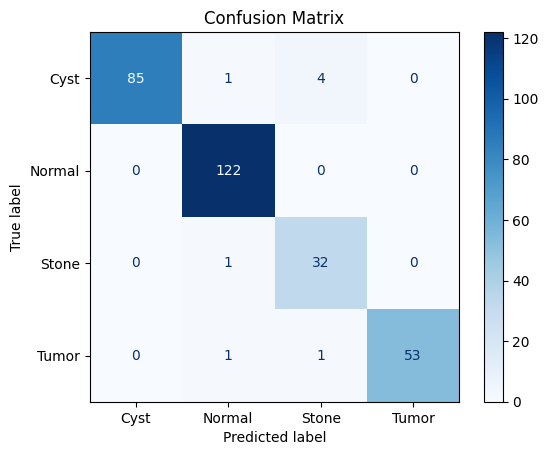

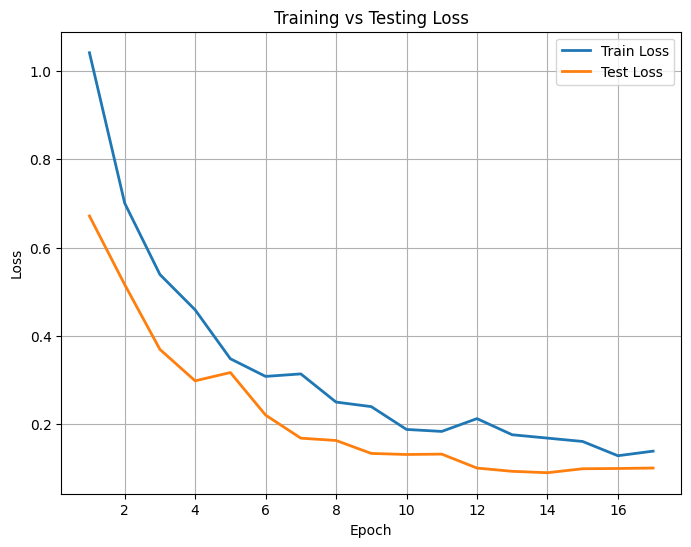

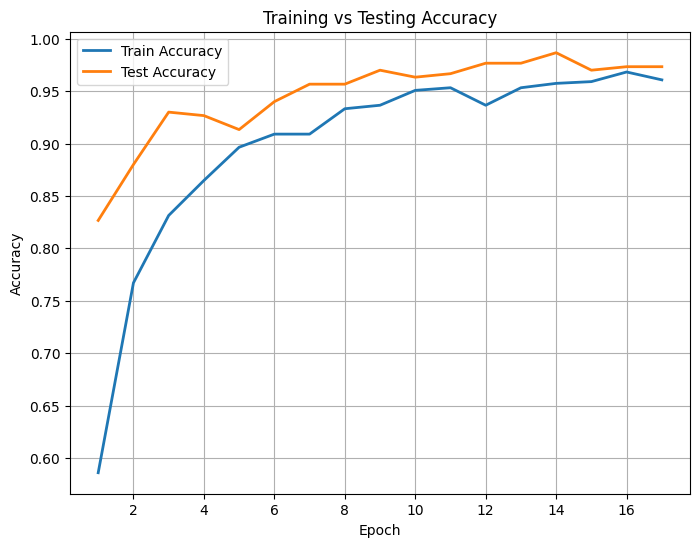

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# PLOTS:
# 1. Confusion Matrix
# 2. Training vs Testing Loss
# 3. Training vs Testing Accuracy
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

# ============================================================
# 1. LOAD METRICS
# ============================================================

metrics_df = pd.read_csv("/content/training_metrics.csv")

cm_df = pd.read_csv("/content/confusion_matrix.csv")

cm = cm_df.values

# ============================================================
# 2. CLASS NAMES
# ============================================================

classes = [
    "Cyst",
    "Normal",
    "Stone",
    "Tumor"
]

# ============================================================
# 3. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")

plt.savefig(
    "/content/confusion_matrix_plot.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 4. TRAINING vs TESTING LOSS
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    metrics_df["epoch"],
    metrics_df["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    metrics_df["epoch"],
    metrics_df["test_loss"],
    label="Test Loss",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Testing Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/loss_curve.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 5. TRAINING vs TESTING ACCURACY
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    metrics_df["epoch"],
    metrics_df["train_acc"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    metrics_df["epoch"],
    metrics_df["test_acc"],
    label="Test Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Testing Accuracy")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/accuracy_curve.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 6. OPTIONAL: DOWNLOAD PLOTS
# ============================================================

from google.colab import files

files.download("/content/confusion_matrix_plot.png")

files.download("/content/loss_curve.png")

files.download("/content/accuracy_curve.png")

          0         1         2         3         4         5         6  \
0 -0.025840 -0.370289 -0.215228  0.135875  0.232839 -0.227998  0.151757   
1 -0.153352 -0.562771 -0.326070  0.154246  0.308989 -0.420138  0.293244   
2 -0.130990 -0.377680 -0.196029  0.091368  0.314301 -0.251673  0.285811   
3 -0.296236 -0.538764 -0.336348  0.100451  0.324118 -0.392228  0.279116   
4 -0.154989 -0.522657 -0.319081  0.168137  0.184936 -0.406870  0.093266   

          7         8         9  ...       504       505       506       507  \
0 -0.412751 -0.152555  0.000097  ...  0.010847 -0.068533 -0.195539  0.332368   
1 -0.668250 -0.089771 -0.041589  ... -0.176908  0.220606 -0.171896  0.189461   
2 -0.573752 -0.022598 -0.051057  ...  0.115899  0.138780 -0.246258  0.180221   
3 -0.595003  0.000224 -0.030979  ... -0.132594 -0.057385  0.100601 -0.029691   
4 -0.568364  0.047597 -0.118534  ... -0.131466 -0.215409 -0.130065 -0.083790   

        508       509       510       511  label  prediction  
0  0.

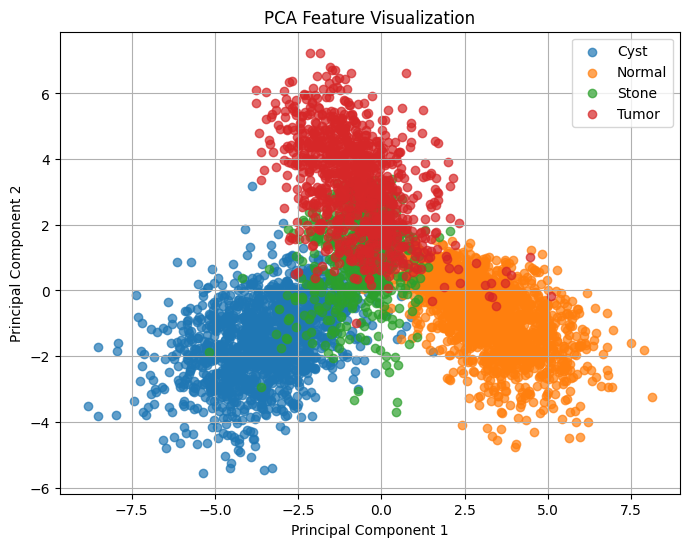


Running t-SNE...
t-SNE Completed!


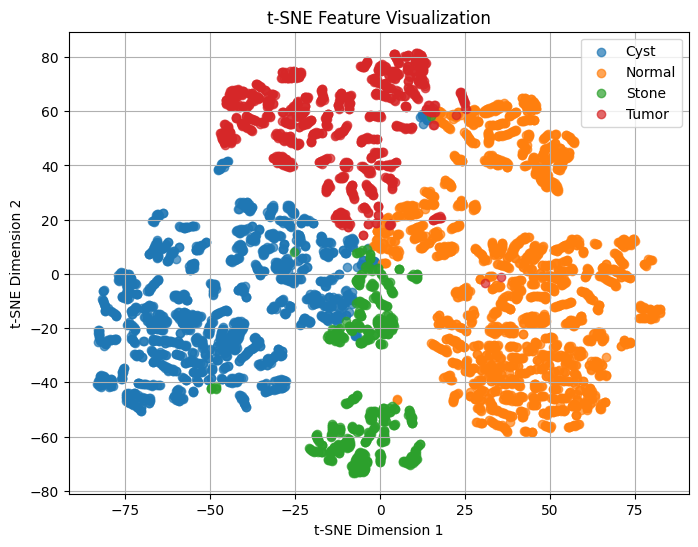


Explained Variance Ratio:
[0.32361303 0.15447461]

Total Explained Variance: 47.81%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# PCA & t-SNE FEATURE VISUALIZATION
# ============================================================

# This code uses:
# feature_embeddings.csv
#
# Saved earlier during evaluation
#
# Generates:
# 1. PCA Plot
# 2. t-SNE Plot
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

# ============================================================
# 2. LOAD FEATURE EMBEDDINGS
# ============================================================

feature_df = pd.read_csv(
    "/content/feature_embeddings.csv"
)

print(feature_df.head())

# ============================================================
# 3. SEPARATE FEATURES & LABELS
# ============================================================

# Remove label & prediction columns
X = feature_df.drop(
    columns=["label", "prediction"]
).values

# Labels
# ============================================================
# Convert Numeric Labels to Actual Class Names
# ============================================================

label_map = {

    0: "Cyst",

    1: "Normal",

    2: "Stone",

    3: "Tumor"
}

# Convert labels
y_numeric = feature_df["label"].values

y = np.array([
    label_map[label]
    for label in y_numeric
])

print("\nFeature Shape:", X.shape)

print("Labels Shape :", y.shape)

# ============================================================
# 4. PCA (2D)
# ============================================================

print("\nRunning PCA...")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("PCA Completed!")

# ============================================================
# 5. PCA PLOT
# ============================================================

plt.figure(figsize=(8,6))

classes = np.unique(y)

for cls in classes:

    idx = y == cls

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=cls,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Feature Visualization")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/pca_plot.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 6. t-SNE
# ============================================================

print("\nRunning t-SNE...")

tsne = TSNE(

    n_components=2,

    perplexity=30,

    learning_rate='auto',

    init='pca',

    random_state=42
)

X_tsne = tsne.fit_transform(X)

print("t-SNE Completed!")

# ============================================================
# 7. t-SNE PLOT
# ============================================================

plt.figure(figsize=(8,6))

for cls in classes:

    idx = y == cls

    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=cls,
        alpha=0.7
    )

plt.xlabel("t-SNE Dimension 1")

plt.ylabel("t-SNE Dimension 2")

plt.title("t-SNE Feature Visualization")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/tsne_plot.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 8. EXPLAINED VARIANCE (OPTIONAL)
# ============================================================

explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")

print(explained_variance)

print(
    f"\nTotal Explained Variance: "
    f"{np.sum(explained_variance)*100:.2f}%"
)

# ============================================================
# 9. DOWNLOAD PLOTS
# ============================================================

from google.colab import files

files.download("/content/pca_plot.png")

files.download("/content/tsne_plot.png")